# Model Training — Heart Disease Prediction using Machine Learning

**Author:** Md Sagor Hossain

Full pipeline: preprocessing → EDA → outlier removal → train/test split → cross-validation → model building → evaluation → feature selection → interpretation.

> For a deeper, visualization-only exploration of the raw data, see `EDA.ipynb`.

## 1. Data Description

918 patient records, 11 clinical features, binary target `HeartDisease` (1 = disease present, 0 = normal).

## 2. Importing Libraries & Setting Up Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Environment ready.")

Environment ready.


## 3. Loading Dataset

In [2]:
df = pd.read_csv("../data/raw/heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 4. Data Cleaning & Preprocessing

In [3]:
df = df.drop_duplicates()

df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())

print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [4]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])
df_encoded.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2,0


## 5. Exploratory Data Analysis (quick check)

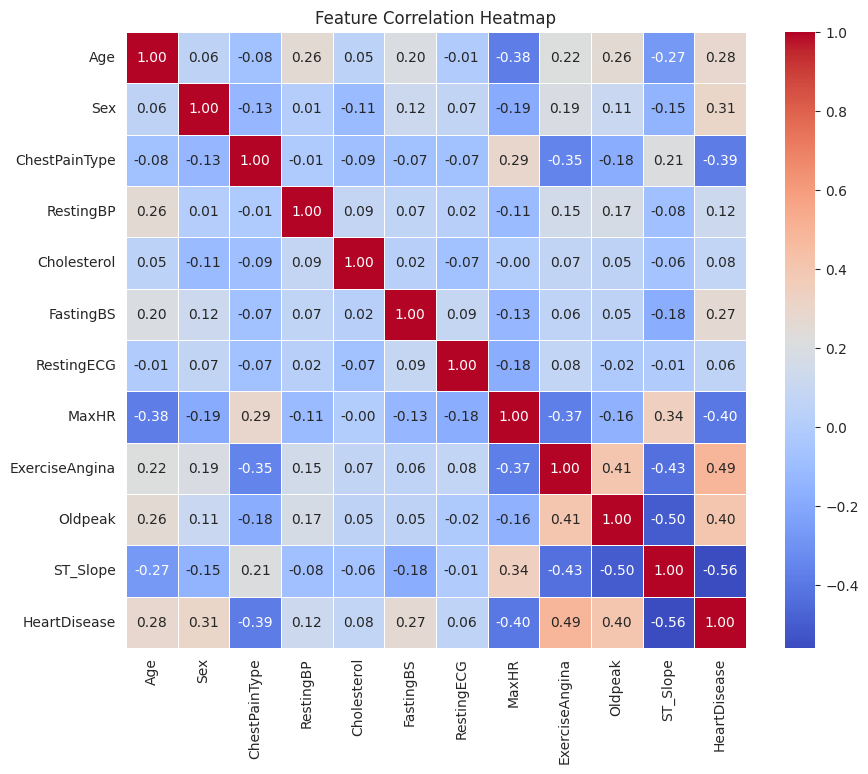

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## 6. Outlier Detection & Removal

In [6]:
def detect_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)], lower, upper

df_clean = df_encoded.copy()
for col in ["RestingBP", "Cholesterol"]:
    _, lower, upper = detect_outliers_iqr(df_clean, col)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Shape before:", df_encoded.shape, " Shape after:", df_clean.shape)

Shape before: (918, 12)  Shape after: (851, 12)


## 7. Training & Test Split

In [7]:
X = df_clean.drop("HeartDisease", axis=1)
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Train: (680, 11)  Test: (171, 11)


## 8. Cross Validation

In [8]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models_for_cv = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}
for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring="accuracy")
    print(f"{name:20s}  Mean CV Accuracy: {scores.mean():.4f}  (+/- {scores.std():.4f})")

Logistic Regression   Mean CV Accuracy: 0.8324  (+/- 0.0234)
KNN                   Mean CV Accuracy: 0.8397  (+/- 0.0273)
SVM                   Mean CV Accuracy: 0.8574  (+/- 0.0274)
Decision Tree         Mean CV Accuracy: 0.7721  (+/- 0.0345)


Random Forest         Mean CV Accuracy: 0.8426  (+/- 0.0300)
XGBoost               Mean CV Accuracy: 0.8382  (+/- 0.0439)


## 9. Model Building

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

In [10]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [11]:
svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [14]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     eval_metric="logloss", random_state=RANDOM_STATE)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

In [15]:
voting_clf = VotingClassifier(estimators=[("lr", log_reg), ("rf", rf), ("xgb", xgb)], voting="soft")
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)

## 10. Model Evaluation & Comparison

In [16]:
predictions = {
    "Logistic Regression": y_pred_lr, "KNN": y_pred_knn, "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt, "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb, "Voting Ensemble": y_pred_voting,
}
results_table = []
for name, y_pred in predictions.items():
    results_table.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })
results_df = pd.DataFrame(results_table).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.894737,0.895833,0.914894,0.905263
1,SVM,0.894737,0.904255,0.904255,0.904255
2,Random Forest,0.888889,0.903226,0.893617,0.898396
3,Voting Ensemble,0.888889,0.903226,0.893617,0.898396
4,Logistic Regression,0.883041,0.911111,0.872340,0.891304
5,XGBoost,0.883041,0.902174,0.882979,0.892473
6,Decision Tree,0.847953,0.877778,0.840426,0.858696


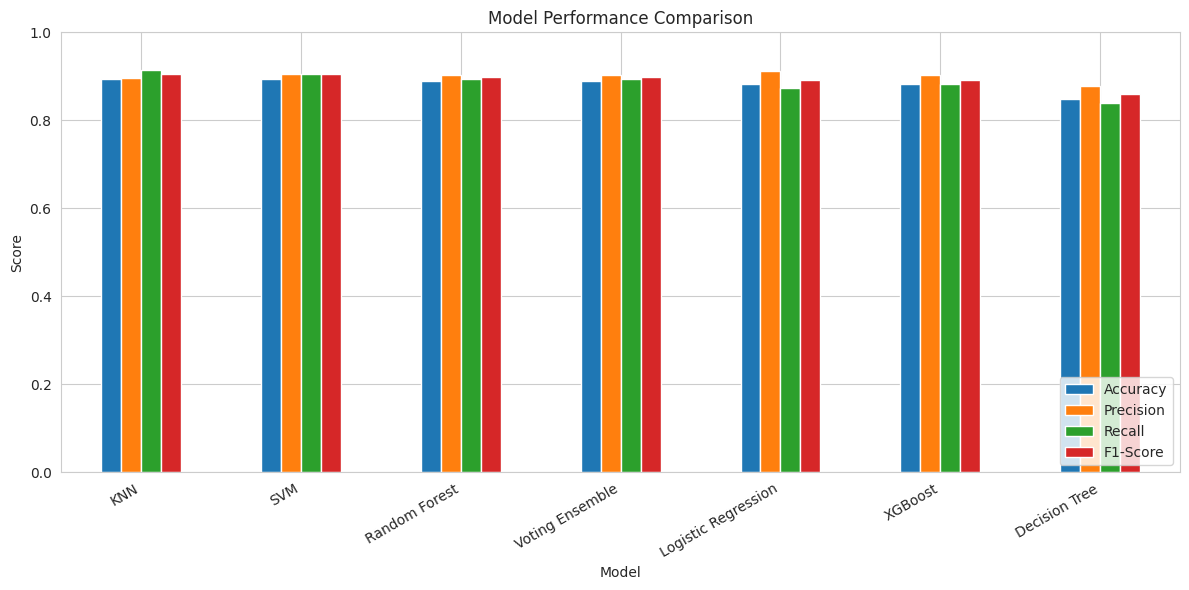

In [17]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [18]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best performing model: {best_model_name}  (Accuracy: {results_df.iloc[0]['Accuracy']:.4f})")

Best performing model: KNN  (Accuracy: 0.8947)


## 11. Feature Selection

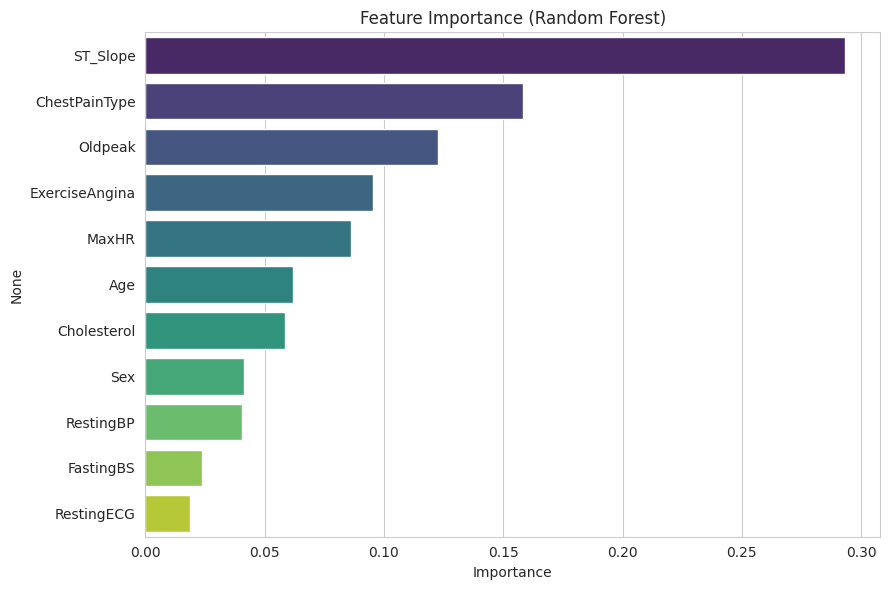

ST_Slope          0.293221
ChestPainType     0.158136
Oldpeak           0.122493
ExerciseAngina    0.095227
MaxHR             0.086295
Age               0.061947
Cholesterol       0.058598
Sex               0.041256
RestingBP         0.040365
FastingBS         0.023717
RestingECG        0.018746
dtype: float64

In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
importances

## 12. Model Evaluation (Interpretation)

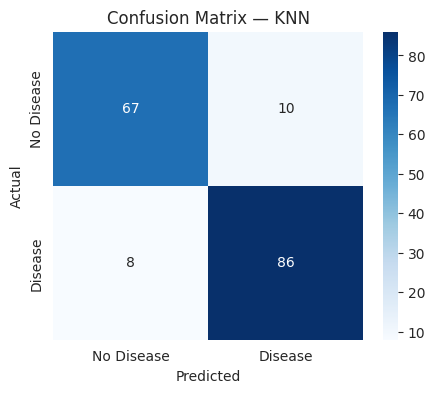

              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        77
     Disease       0.90      0.91      0.91        94

    accuracy                           0.89       171
   macro avg       0.89      0.89      0.89       171
weighted avg       0.89      0.89      0.89       171



In [20]:
best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix — {best_model_name}"); plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.show()
print(classification_report(y_test, best_pred, target_names=["No Disease", "Disease"]))

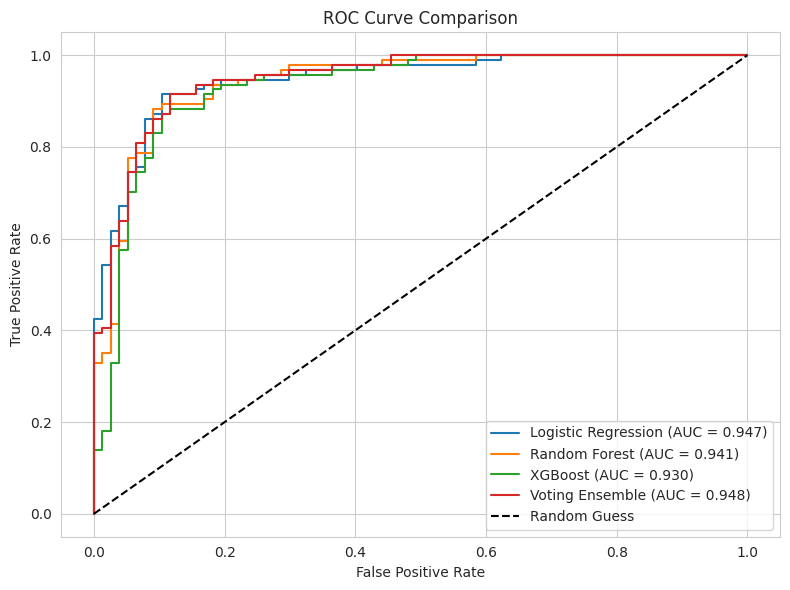

In [21]:
plt.figure(figsize=(8, 6))
roc_models = {"Logistic Regression": log_reg, "Random Forest": rf, "XGBoost": xgb, "Voting Ensemble": voting_clf}
for name, model in roc_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [22]:
import joblib, os
os.makedirs("../models", exist_ok=True)
joblib.dump(voting_clf, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")
print("Model and scaler saved.")

Model and scaler saved.


## 13. Conclusion

- Cleaned invalid zero values in `Cholesterol`/`RestingBP`, removed duplicates and outliers.
- `ST_Slope`, `ChestPainType`, `ExerciseAngina`, and `Oldpeak` are the strongest predictors.
- Compared 7 models; the best model was saved for reuse via `src/predict.py` or the Streamlit app.

**Future Work:** hyperparameter tuning, Streamlit/Flask deployment (see `app/streamlit_app.py`), testing on larger external datasets.